This notebook shows how to build a basic tournament and view the results.

In [293]:
import random
import axelrod as axl
%matplotlib inline

print(len(axl.strategies))
axl.strategies

240


[axelrod.strategies.memoryone.ALLCorALLD,
 axelrod.strategies.memorytwo.AON2,
 axelrod.strategies.apavlov.APavlov2006,
 axelrod.strategies.apavlov.APavlov2011,
 axelrod.strategies.adaptive.Adaptive,
 axelrod.strategies.titfortat.AdaptiveTitForTat,
 axelrod.strategies.adaptor.AdaptorBrief,
 axelrod.strategies.adaptor.AdaptorLong,
 axelrod.strategies.grudger.Aggravater,
 axelrod.strategies.titfortat.Alexei,
 axelrod.strategies.alternator.Alternator,
 axelrod.strategies.hunter.AlternatorHunter,
 axelrod.strategies.cycler.AntiCycler,
 axelrod.strategies.titfortat.AntiTitForTat,
 axelrod.strategies.appeaser.Appeaser,
 axelrod.strategies.qlearner.ArrogantQLearner,
 axelrod.strategies.averagecopier.AverageCopier,
 axelrod.strategies.backstabber.BackStabber,
 axelrod.strategies.better_and_better.BetterAndBetter,
 axelrod.strategies.titfortat.Bully,
 axelrod.strategies.titfortat.BurnBothEnds,
 axelrod.strategies.bush_mosteller.BushMosteller,
 axelrod.strategies.calculator.Calculator,
 axelrod.s

In [294]:
# Display the default game matrix
game = axl.game.Game()
print("Default Score Matrix:")
print(f"R (Reward for mutual cooperation): {game.RPST()[1]}")
print(f"P (Punishment for mutual defection): {game.RPST()[2]}")
print(f"S (Sucker's payoff - cooperate while opponent defects): {game.RPST()[3]}")
print(f"T (Temptation to defect - defect while opponent cooperates): {game.RPST()[0]}")


Default Score Matrix:
R (Reward for mutual cooperation): 1
P (Punishment for mutual defection): 0
S (Sucker's payoff - cooperate while opponent defects): 5
T (Temptation to defect - defect while opponent cooperates): 3


In [295]:
# Create matches between two players:

import axelrod as axl
players = (axl.Alternator(), axl.TitForTat())
match = axl.Match(players, 5)
interactions = match.play()
interactions


[(C, C), (D, C), (C, D), (D, C), (C, D)]

In [296]:
#Build full tournaments between groups of players:

players = (axl.Cooperator(), axl.Alternator(), axl.TitForTat(), axl.ZDExtort2())
tournament = axl.Tournament(players)
print(f"Turns: {tournament.turns}")
print(f"Repetitions: {tournament.repetitions}")
results = tournament.play()
results.ranked_names



Turns: 200
Repetitions: 10


Analysing: 100%|██████████| 25/25 [00:00<00:00, 398.41it/s]


['Alternator',
 'ZD-Extort-2: 0.1111111111111111, 0.5',
 'Cooperator',
 'Tit For Tat']

In [297]:
# Study the evolutionary process using a Moran process:

players = (axl.Cooperator(), axl.Alternator(), axl.TitForTat())
mp = axl.MoranProcess(players)
populations = mp.play()
populations  



[Counter({'Cooperator': 1, 'Alternator': 1, 'Tit For Tat': 1}),
 Counter({'Tit For Tat': 2, 'Alternator': 1}),
 Counter({'Tit For Tat': 3})]

# tournament (see Matches.ipynb for better visuals)

Analysing: 100%|██████████| 25/25 [00:00<00:00, 324.54it/s]
/var/folders/23/j90lq3412lbfx3drxzf3_9wh0000gn/T/ipykernel_70529/1239415484.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


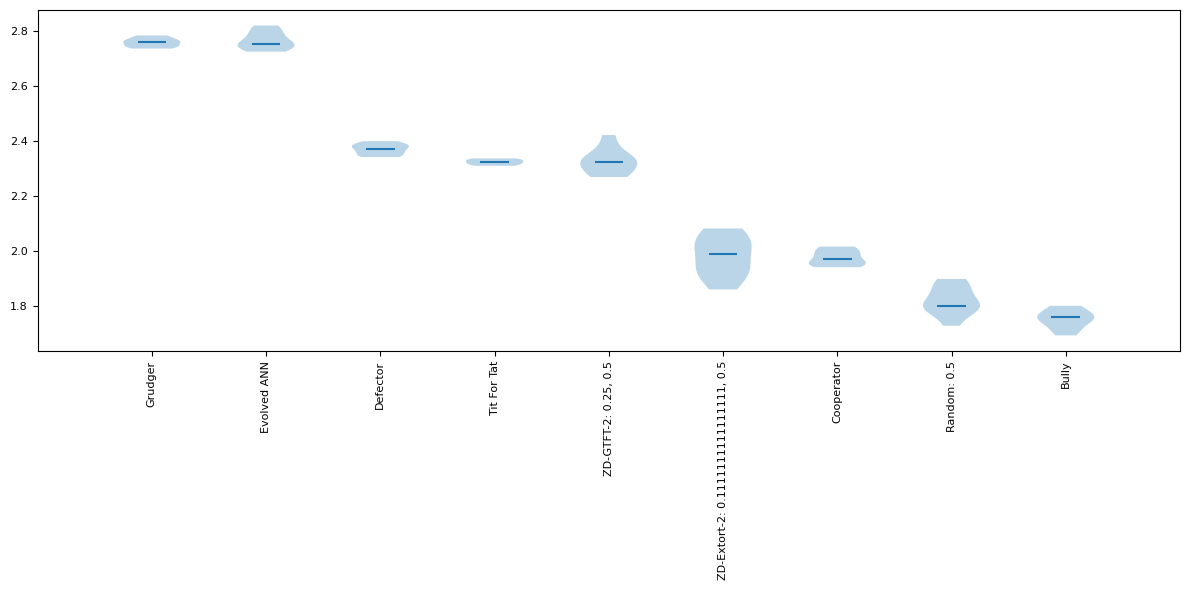

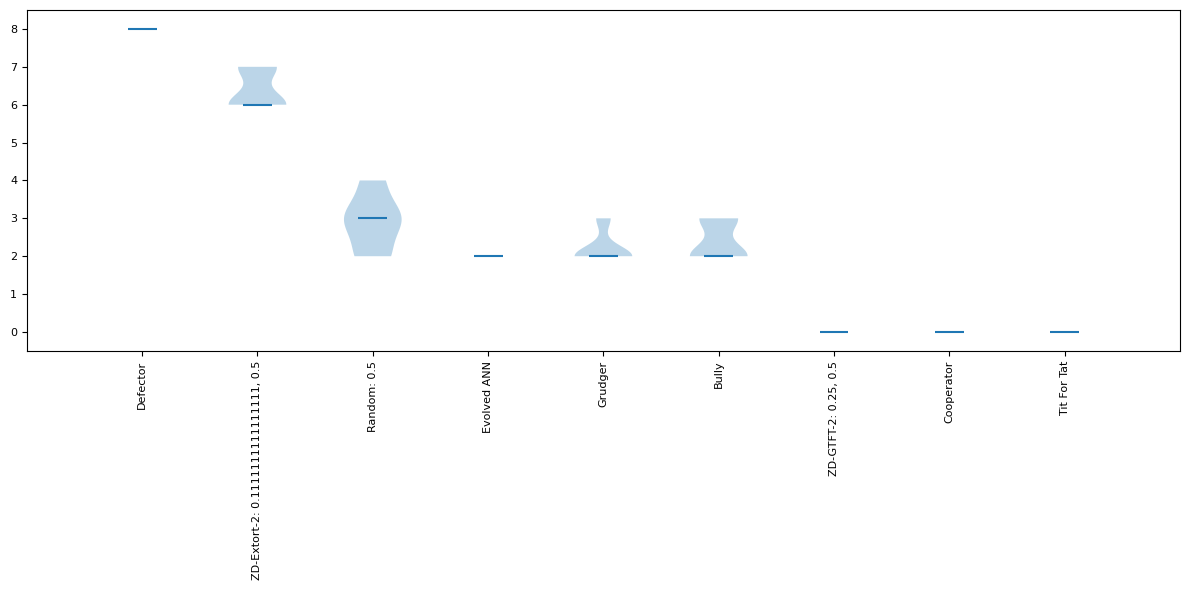

In [328]:

# strategies.append(axl.Random())
# strategies.append(axl.ZDGTFT2())
# strategies.append(axl.ZDExtort2())


# Define players from the basic tournament
strategies = [
    axl.TitForTat(),
    axl.Defector(),
    axl.Cooperator(),
    axl.Bully(),
    axl.Grudger(),  # Grim
    axl.Random(),
    axl.ZDGTFT2(),
    axl.ZDExtort2(),
    axl.EvolvedANN()
]


tournament = axl.Tournament(strategies)
results = tournament.play()
results.ranked_names

plot = axl.Plot(results)
plot.boxplot();

p = plot.winplot()
p.show()


Analysing: 100%|██████████| 25/25 [00:00<00:00, 327.69it/s]


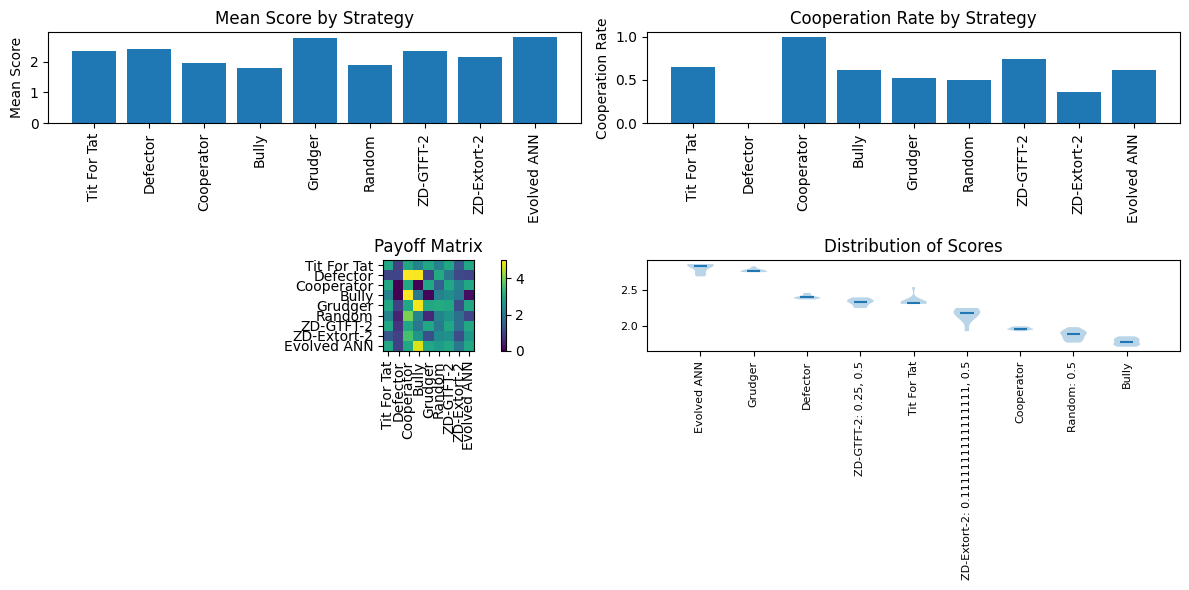

In [329]:
import axelrod as axl
import numpy as np
import matplotlib.pyplot as plt



# Run tournament
tournament = axl.Tournament(strategies, turns=100)
results = tournament.play()

# Get player names in order
player_names = [p.name for p in strategies]

# Convert to numpy arrays for easier manipulation
normalised_scores = np.array(results.normalised_scores)
player_ranks = results.ranking

# Plot visualizations
plt.figure(figsize=(16, 12))

# 1. Mean score over all opponents
plt.subplot(2, 2, 1)
mean_scores = np.mean(normalised_scores, axis=1)
plt.bar(range(len(player_names)), mean_scores)
plt.xticks(range(len(player_names)), player_names, rotation=90)
plt.ylabel('Mean Score')
plt.title('Mean Score by Strategy')

# 2. Cooperation rate
plt.subplot(2, 2, 2)
cooperation_rates = np.array(results.cooperating_rating)
plt.bar(range(len(player_names)), cooperation_rates)
plt.xticks(range(len(player_names)), player_names, rotation=90)
plt.ylabel('Cooperation Rate')
plt.title('Cooperation Rate by Strategy')

# 3. Payoff Matrix as heatmap
plt.subplot(2, 2, 3)
plt.imshow(results.payoff_matrix, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(player_names)), player_names, rotation=90)
plt.yticks(range(len(player_names)), player_names)
plt.title('Payoff Matrix')

# 4. Boxplot of scores
plt.subplot(2, 2, 4)
plot = axl.Plot(results)
plot.boxplot(ax=plt.gca())
plt.title('Distribution of Scores')

plt.tight_layout()

/var/folders/23/j90lq3412lbfx3drxzf3_9wh0000gn/T/ipykernel_70529/1490695551.py:67: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


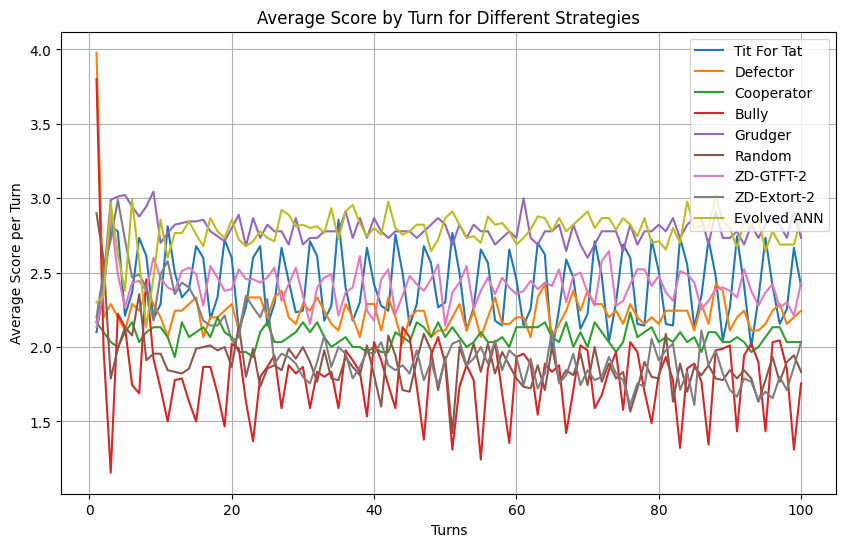

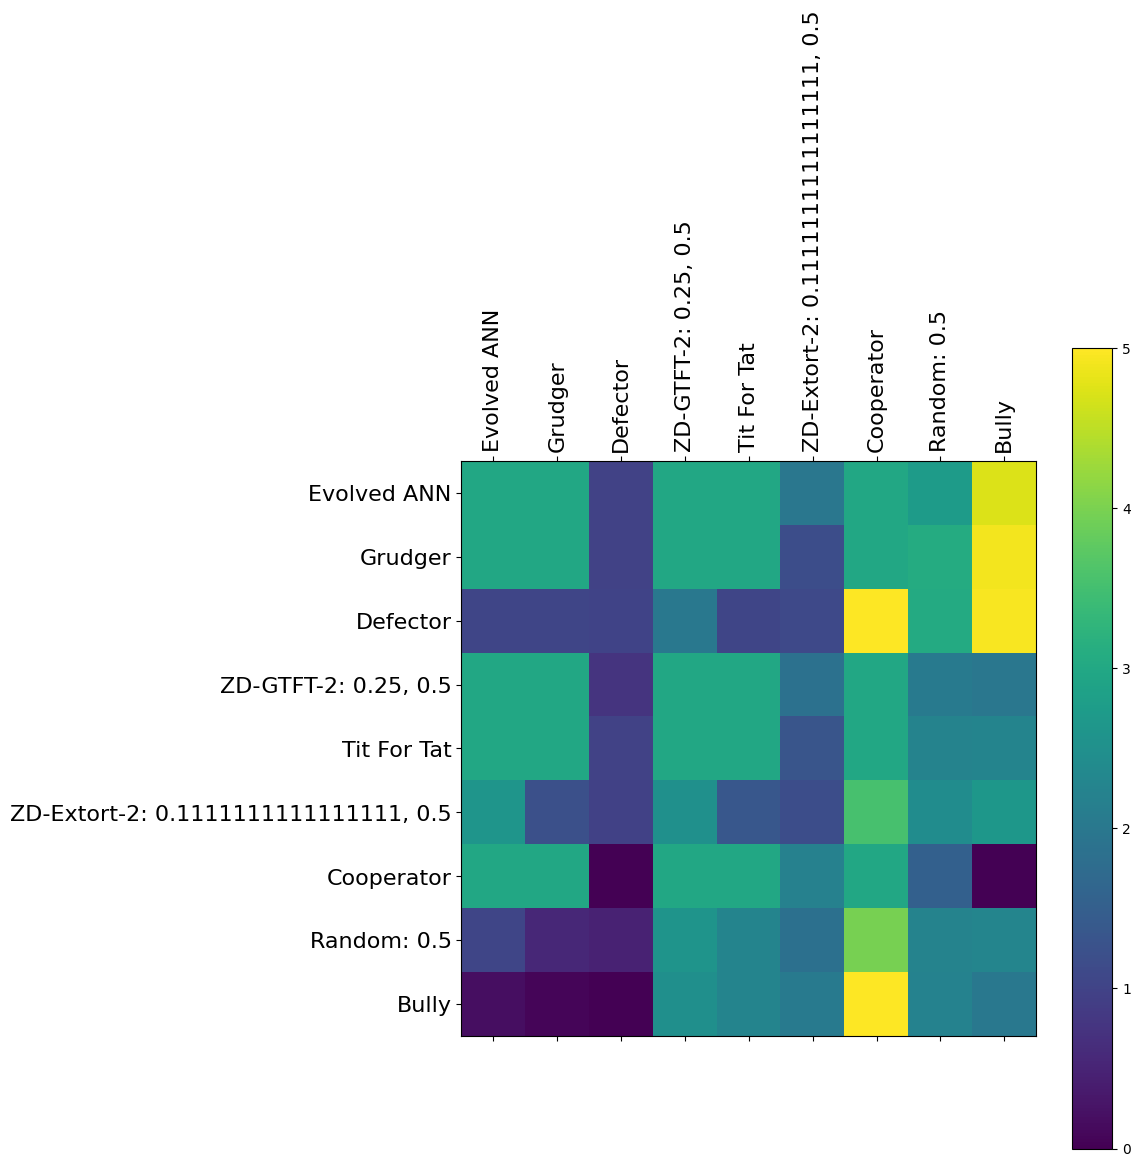

In [330]:
import axelrod as axl
import numpy as np
import matplotlib.pyplot as plt



turns = 100
matches = 10  # Number of matches to average over

# Dictionary to store scores by turn
scores_by_turn = {p.name: np.zeros(turns) for p in strategies}
match_counts = {p.name: 0 for p in strategies}

# Get the game to calculate scores properly
game = axl.game.Game()

# Play matches between all pairs of strategies
for i, p1 in enumerate(strategies):
    for j, p2 in enumerate(strategies):
        if i <= j:  # Include self-play
            # Play multiple matches and average
            for _ in range(matches):
                # Reset players before each match
                p1.reset()
                p2.reset()
                
                # Create and play match
                match = axl.Match([p1, p2], turns=turns)
                interactions = match.play()
                
                # Calculate scores for each turn manually
                p1_scores = np.zeros(turns)
                p2_scores = np.zeros(turns)
                
                for turn, (move1, move2) in enumerate(interactions):
                    # Get score for this interaction based on the game
                    score1, score2 = game.score((move1, move2))
                    p1_scores[turn] = score1
                    p2_scores[turn] = score2
                
                # Add scores to running totals
                scores_by_turn[p1.name] += p1_scores
                match_counts[p1.name] += 1
                
                if i != j:  # If not self-play
                    scores_by_turn[p2.name] += p2_scores
                    match_counts[p2.name] += 1

# Calculate averages
for name in scores_by_turn:
    scores_by_turn[name] /= match_counts[name]

# Plot turn-by-turn scores
plt.figure(figsize=(10, 6))
for name, scores in scores_by_turn.items():
    plt.plot(range(1, turns+1), scores, label=name)

plt.xlabel('Turns')
plt.ylabel('Average Score per Turn')
plt.title('Average Score by Turn for Different Strategies')
plt.legend()
plt.grid(True)



p = plot.payoff()
p.show()


# Head-to-head

In [302]:
# Create a memory-one strategy with custom probabilities

p1 = 1  # X player
p4 = 0

custom_strategy1 = axl.MemoryOnePlayer(
    four_vector=(p1, 1, 0, p4)  # (P(C|CC), P(C|CD), P(C|DC), P(C|DD))
)

custom_strategy2 = axl.MemoryOnePlayer(
    four_vector=(0.7, 0.7, 0.7, 0.7)  # (P(C|CC), P(C|CD), P(C|DC), P(C|DD))
)

# def calculate_sY(p1: float, p4: float, P: float = 1, R: float = 3) -> float:
#     numerator = (1 - p1) * P + p4 * R
#     denominator = (1 - p1) + p4
#     return numerator / denominator

# # Example usage:
# score = calculate_sY(p1, p4)
# print(f"s_Y = {score:.4f}")  # Output: s_Y = 1.8000

In [303]:
#Build full tournaments between groups of players:

players = (custom_strategy1, custom_strategy1)
tournament = axl.Tournament(players)
print(f"Turns: {tournament.turns}")
print(f"Repetitions: {tournament.repetitions}")
results = tournament.play()
results.ranked_names



Turns: 200
Repetitions: 10


Analysing: 100%|██████████| 25/25 [00:00<00:00, 407.87it/s]


['Generic Memory One Player: (1, 1, 0, 0), C',
 'Generic Memory One Player: (1, 1, 0, 0), C']

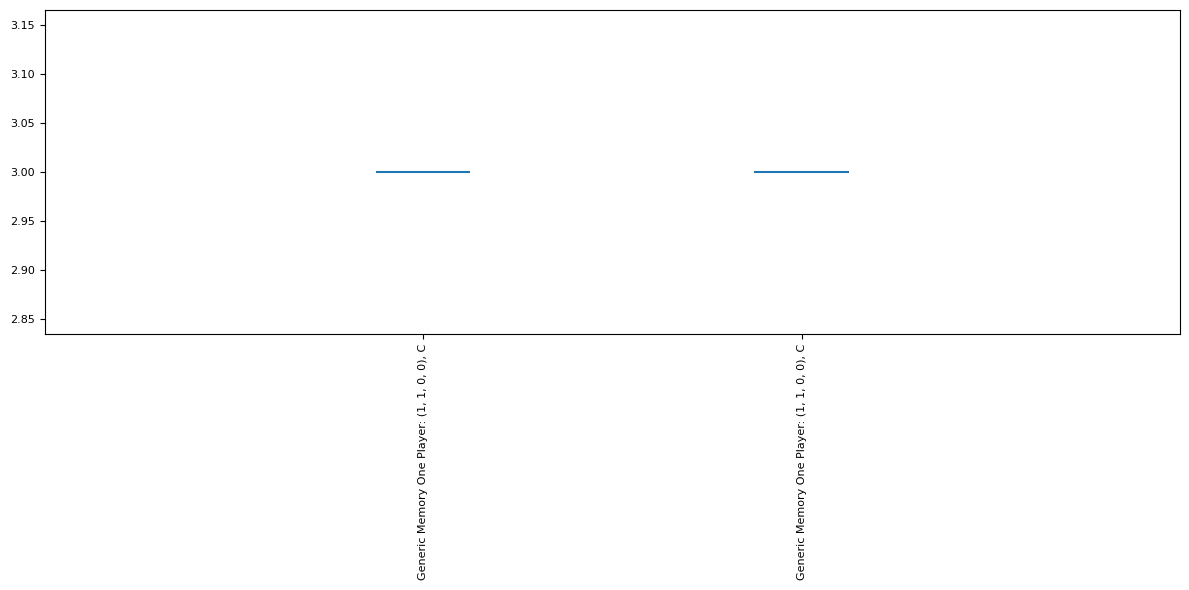

In [304]:
plot = axl.Plot(results)
plot.boxplot();

max phi = 0.0476


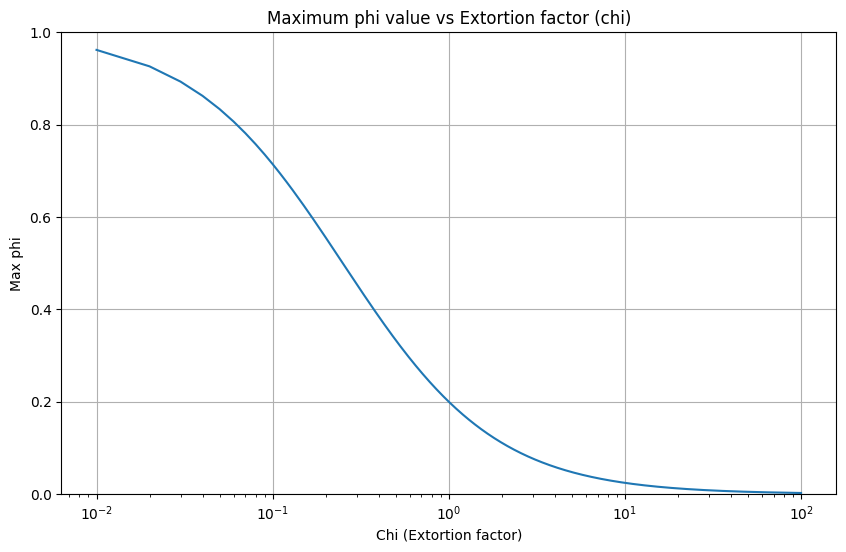

In [292]:
def compute_ratio(
    chi: float,
    P: float = 1,  # Punishment payoff (mutual defection)
    S: float = 0,  # Sucker's payoff (you cooperate, opponent defects)
    T: float = 5,  # Temptation payoff (you defect, opponent cooperates)
) -> float:
    """
    Compute the ratio from Press & Dyson's ZD strategy framework.    
    Returns:
        Computed ratio: (P - S) / [(P - S) + χ(T - P)]
    """
    numerator = P - S
    denominator = numerator + chi * (T - P)
    return numerator / denominator

# Example usage (matching ZD-Extort-2 parameters):
chi = 5  # Extortion factor
result = compute_ratio(chi)
print(f"max phi = {result:.4f}")  

# Plot chi vs max-phi
import numpy as np
import matplotlib.pyplot as plt

chi_values = np.linspace(0.01, 100, 10000)  # Range from near 0 to 100
phi_values = [compute_ratio(chi) for chi in chi_values]

plt.figure(figsize=(10, 6))
plt.plot(chi_values, phi_values)
plt.title('Maximum phi value vs Extortion factor (chi)')
plt.xlabel('Chi (Extortion factor)')
plt.ylabel('Max phi')
plt.grid(True)
plt.xscale('log')  # Log scale makes it easier to see the relationship
plt.ylim(0, 1)  # phi is always between 0 and 1
plt.show()



Turns: 200
Repetitions: 10


Analysing: 100%|██████████| 25/25 [00:00<00:00, 349.38it/s]


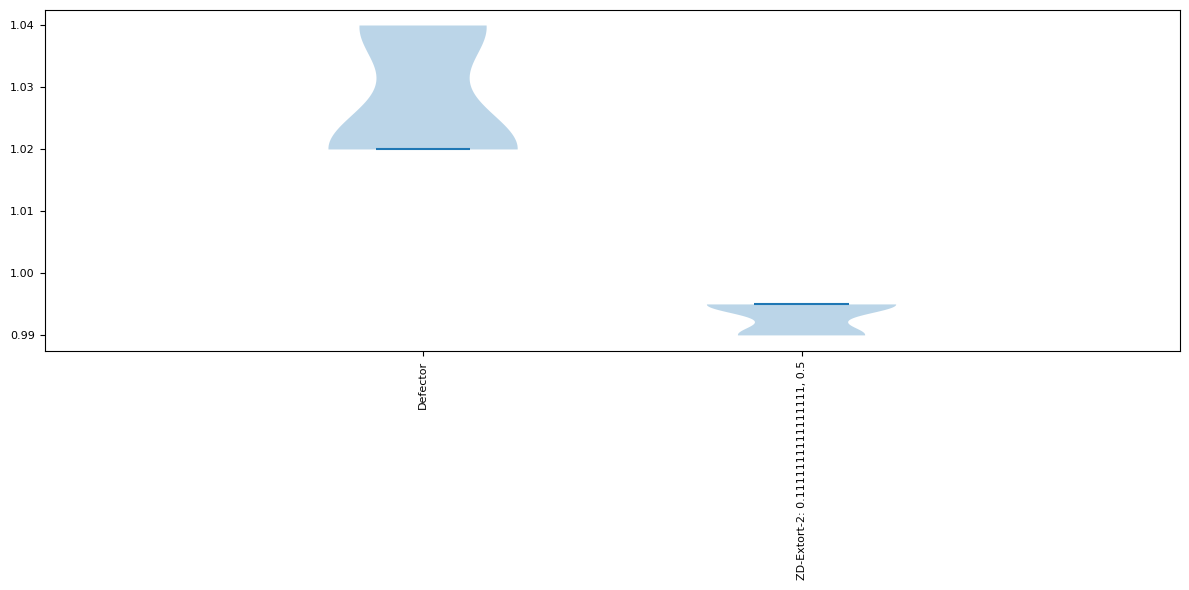

In [280]:


# custom extortionate ZD

# Extortionate Strategies
# ZDExtortion: The general extortionate ZD strategy class where you can customize parameters
# ZDExtort2: Fixed extortion factor of 2
# ZDExtort2v2: A variant of ZDExtort2 with slightly different parameters
# ZDExtort3: Fixed extortion factor of 3
# ZDExtort4: Fixed extortion factor of 4


custom_zd_extort1 = axl.ZDExtortion(phi=0.2000)  

custom_strategy2 = axl.MemoryOnePlayer(
    four_vector=(0, 0, 0, 0)  # (P(C|CC), P(C|CD), P(C|DC), P(C|DD))
    # four_vector=(1, 1, 1, 1)  # (P(C|CC), P(C|CD), P(C|DC), P(C|DD))
)

#Build full tournaments between groups of players:

# players = (custom_zd_extort1, axl.Defector())
players = (axl.ZDExtort2(), axl.Defector()) 
# players = (custom_zd_extort1, custom_strategy2)
tournament = axl.Tournament(players)
print(f"Turns: {tournament.turns}")
print(f"Repetitions: {tournament.repetitions}")
results = tournament.play()
results.ranked_names

plot = axl.Plot(results)
plot.boxplot();

# Population dynamics

Analysing: 100%|██████████| 25/25 [00:00<00:00, 348.58it/s]
/var/folders/23/j90lq3412lbfx3drxzf3_9wh0000gn/T/ipykernel_70529/1277066649.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.show()


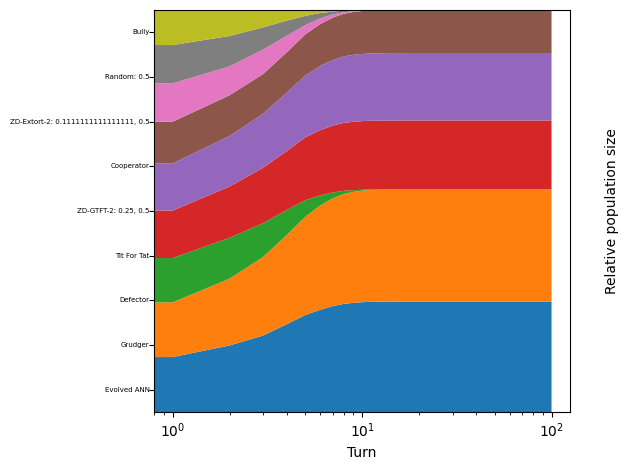

In [331]:

# custom_zd_extort1 = axl.ZDExtortion(phi=0.2000)  
# evo_player2 = axl.EvolvedANN()
# evo_player2 = axl.Adaptive()

# players = [custom_zd_extort1, evo_player2]

players = [
    axl.TitForTat(),
    axl.Defector(),
    axl.Cooperator(),
    axl.Bully(),
    axl.Grudger(),  # Grim
    axl.Random(),
    axl.ZDGTFT2(),
    axl.ZDExtort2(),
    axl.EvolvedANN()
    ]

tournament = axl.Tournament(players)
results = tournament.play()
eco = axl.Ecosystem(results)
eco.reproduce(100) # Evolve the population over 100 time steps


plot = axl.Plot(results)
p = plot.stackplot(eco)
p.show()
